In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-26 13:53:26.450268


# Project Xenium Signature to Sequencing Data - Ernfors integrated dataset
https://www.nature.com/articles/s42003-025-08315-1

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [2]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [3]:
base_dir = "/home/workspace/DRG"

# neurons
input_file = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"
# global 
input_file_global = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"

output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")
plot_out_dir = os.path.join(output_dir, "plots")

# updated reporter identification
reporter_classes_updated_dual_neurons = pd.read_csv(os.path.join(output_dir, 'reporter_classes_updated_dual_neurons.csv'), index_col = 0)

# ernfors ref
ernfors_dir =  os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b/ernfors")

## Load Ernfors ref

In [4]:
adata = sc.read_h5ad(os.path.join(ernfors_dir, "ernfors_ref_complete.h5ad"))

In [5]:
adata

AnnData object with n_obs × n_vars = 44269 × 38178
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'dataset', 'celltype', 'sex', 'predicted_sex'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'scale_data'

In [6]:
# is data scaled (has negatives)?
(adata.X < 0).sum()

0

In [7]:
# is data log norm?
adata.X[0:50,0:50].todense()

matrix([[0.        , 0.        , 0.        , ..., 0.        , 0.24926159,
         0.        ],
        [0.39071304, 0.        , 0.        , ..., 0.        , 0.67093664,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 1.1187088 ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.32090327,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.21850254,
         0.        ]], dtype=float32)

In [8]:
adata.obs['celltype']

10X91_1_AACACGTCAAGTTGTC-1         PEP1.2
10X91_1_AACCGCGCAAATACAG-1         C-LTMR
10X91_1_AACTCTTGTACACCGC-1         C-LTMR
10X91_1_AACTTTCGTAGCGTGA-1         PEP1.4
10X91_1_AAGACCTCACGCCAGT-1         PEP1.4
                                   ...   
GSM6656593_TTTGGTTTCCATTGTT-1    PEP1.1.a
GSM6656593_TTTGGTTTCTATCGCC-1    PEP1.1.a
GSM6656593_TTTGTTGGTCGTAATC-1     Ad-LTMR
GSM6656593_TTTGTTGGTGGACCAA-1    PEP1.1.b
GSM6656593_TTTGTTGTCCCGTGTT-1    PEP1.1.a
Name: celltype, Length: 44269, dtype: category
Categories (23, object): ['Rxfp1', 'TRPM8.1', 'TRPM8.2', 'PEP1.1.a', ..., 'Ab-SA/Field', 'Ab-RA-LTMR', 'Proprioceptor', 'ATF3+']

In [9]:
# # add metadata separately
# meta = pd.read_csv(os.path.join(ernfors_dir, 'cell_metadata.csv'), index_col = 0)
# meta_ordered = meta.reindex(adata.obs_names)

# # verify that no cells were lost or introduced as NaNs
# if meta_ordered.isnull().values.any():
#     print("Warning: Some cells in adata were not found in the metadata CSV.")

# # update obs
# adata.obs = meta_ordered



In [10]:
# # palette for label plotting
# import pickle
# with open(os.path.join(output_dir, 'neuron_label_palette_mapped_ginty.pkl'), 'rb') as f:
#     neuron_label_palette_mapped_ginty = pickle.load(f)

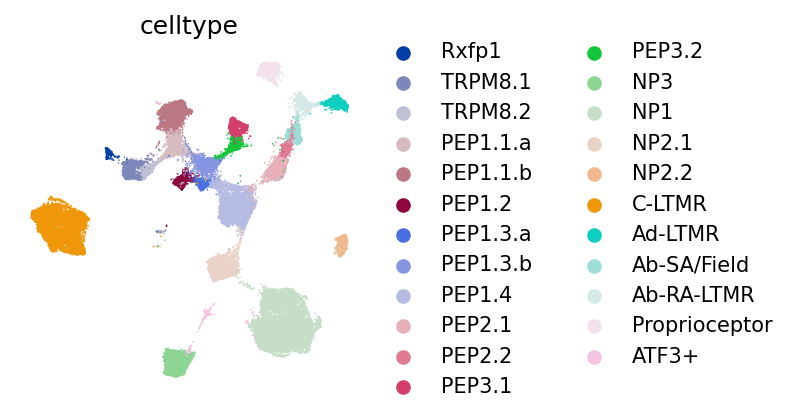

In [11]:
sc.pl.umap(adata, color = 'celltype', frameon = False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"ernfors_reference_umap.pdf"), format='pdf', bbox_inches='tight')

In [12]:
import scanpy as sc

# --- 1. Define your gene list ---
dual_signature_genes = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2"
]

# --- 2. Filter to genes that are actually present in the dataset ---
genes_present = [g for g in dual_signature_genes if g in adata.var_names]

print(f"Using {len(genes_present)} / {len(dual_signature_genes)} genes present in adata:")
print(genes_present)

# --- 3. Score the gene set ---
sc.tl.score_genes(
    adata,
    gene_list=genes_present,
    score_name="dual_positive_signature_score"
)

print("\nAdded adata.obs['dual_positive_signature_score']")

Using 10 / 10 genes present in adata:
['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']

Added adata.obs['dual_positive_signature_score']


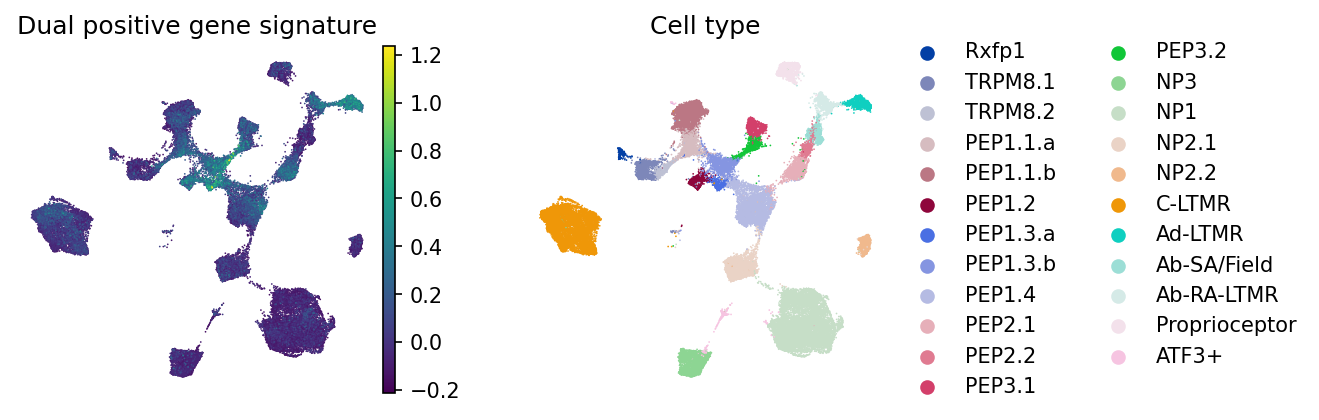

In [13]:
sc.pl.umap(adata, color = ['dual_positive_signature_score', 'celltype'], frameon = False, title = ['Dual positive gene signature', 'Cell type'])

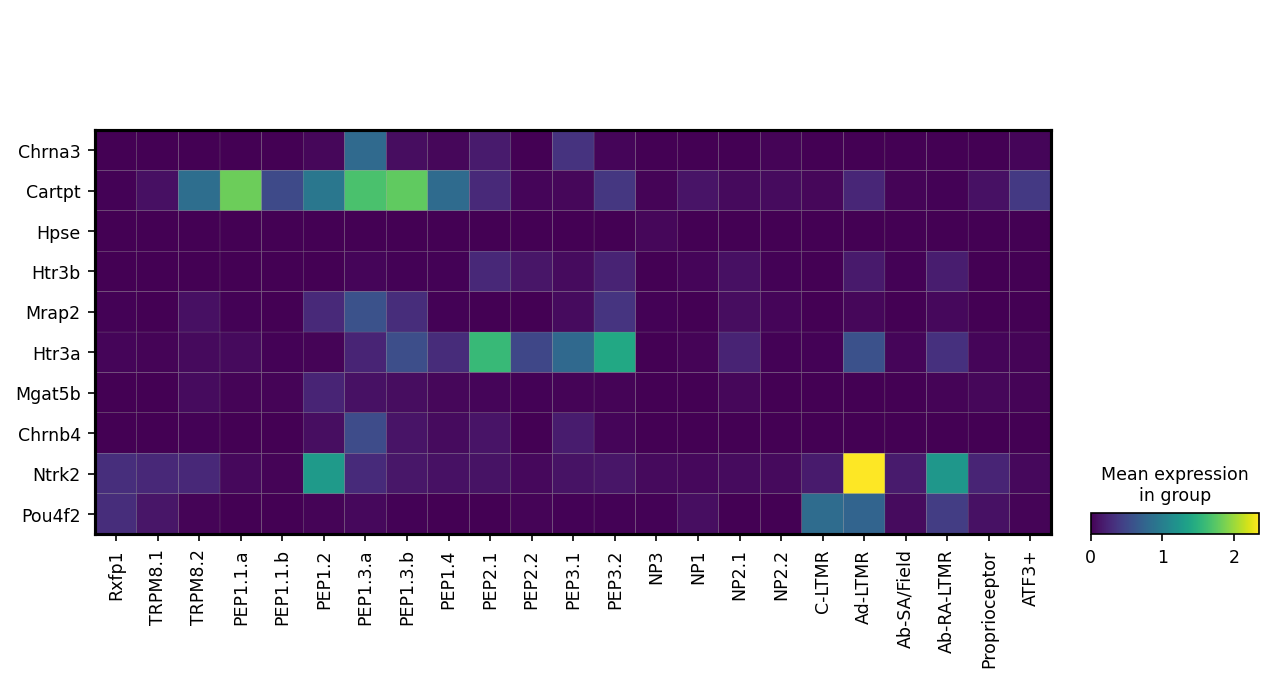

In [14]:
sc.pl.matrixplot(adata, var_names = dual_signature_genes, groupby = 'celltype', swap_axes = True, standard_scale = True)

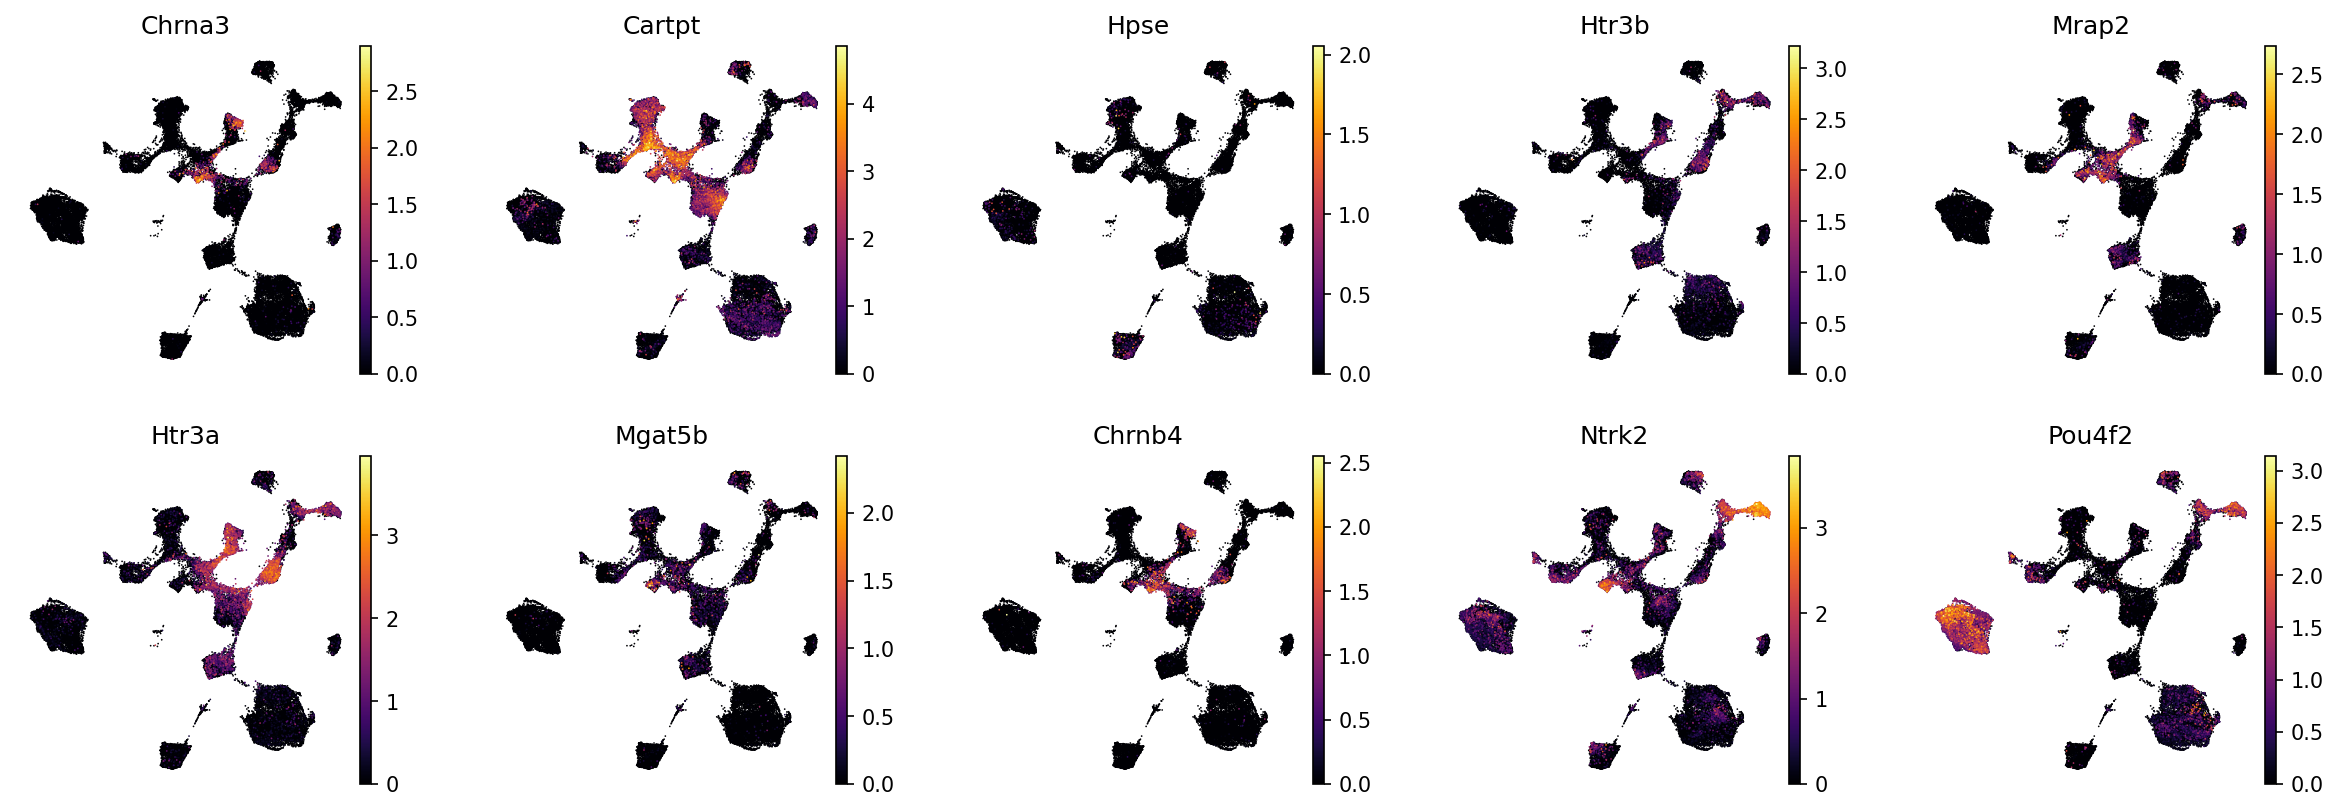

In [15]:
dual_signature_genes
sc.pl.umap(adata, color = dual_signature_genes, ncols = 5, cmap = 'inferno', frameon = False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"ernfors_reference_genes.pdf"), format='pdf', bbox_inches='tight')

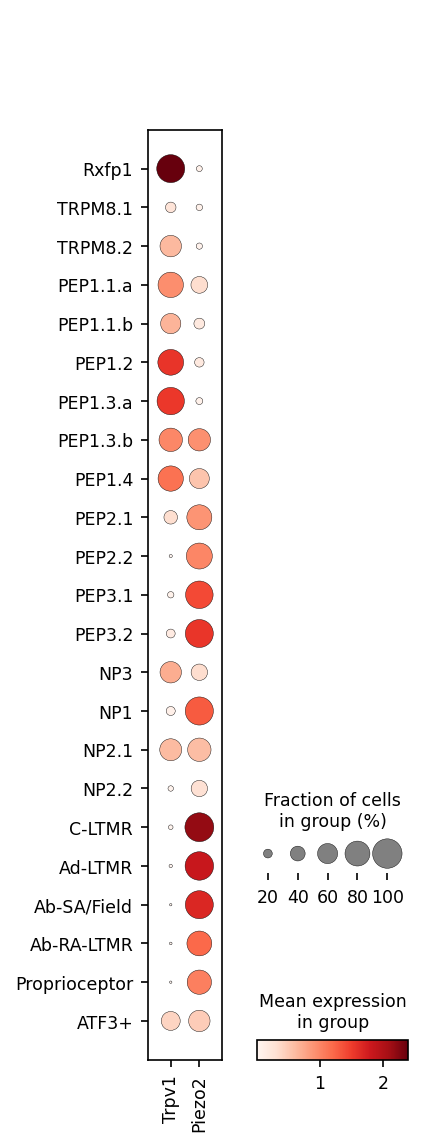

In [18]:
sc.pl.dotplot(adata, var_names = ['Trpv1','Piezo2'], groupby = 'celltype')

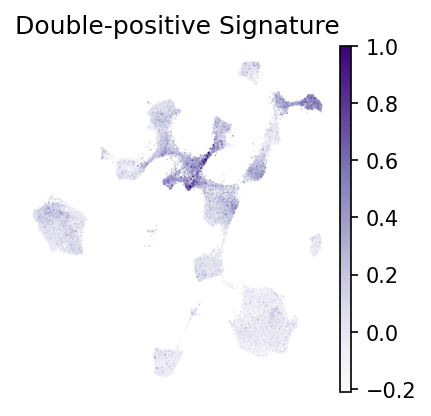

In [19]:
sc.pl.umap(adata, color = ['dual_positive_signature_score'], frameon = False, title = ['Double-positive Signature'], cmap = 'Purples', 
           vmax = 1,
           show=False)
plt.savefig(os.path.join(plot_out_dir, f"ernfors_reference_doublepositive_signature.pdf"), format='pdf', bbox_inches='tight')

/tmp/ipykernel_296/269768560.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


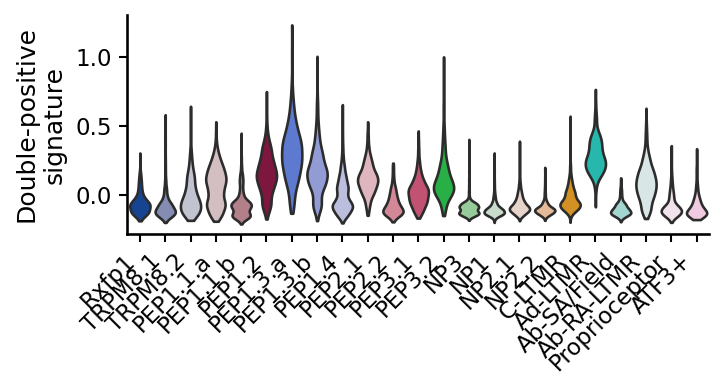

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Minimal clean theme
# ---------------------------
sns.set_theme(style="white")

plt.rcParams['figure.figsize'] = (5, 2)   # <-- ONLY CHANGE (shorter height)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12

# ---------------------------
# Generate violin without showing
# ---------------------------
ax = sc.pl.violin(
    adata,
    keys='dual_positive_signature_score',
    groupby='celltype',
    # palette = neuron_label_palette_mapped_ginty,
    stripplot=False,
    jitter=False,
    inner=None,
    show=False
)

# ---------------------------
# Force visible ticks + labels
# ---------------------------
ax.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

ax.tick_params(
    axis='y',
    which='both',
    left=True,
    right=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

# ---------------------------
# Fix xtick labels (rotation + color)
# ---------------------------
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(
    xticklabels,
    rotation=45,
    ha='right',
    color='black'
)

# ---------------------------
# Labels
# ---------------------------
ax.set_ylabel("Double-positive\nsignature", fontsize=12, color='black')
ax.set_xlabel("")

sns.despine()
plt.tight_layout()
# save
plt.savefig(os.path.join(plot_out_dir, f"ernfors_reference_signature_violin.pdf"), format='pdf', bbox_inches='tight')

plt.show()

In [21]:
plot_out_dir

'/home/workspace/DRG/spatial_mouse_drg_outputs/Kim/update_thresholds_method2b/plots'